# CMPE256 Group 12 - Phase 2
## Rahul Koonantavida Variant

### Packages, Imports, and Configs

In [1]:
!pip -q install pandas pyarrow scikit-learn sentence-transformers torch torchvision torchaudio tqdm faiss-cpu

In [2]:
import os
import math
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

TRAIN_PATH = "/content/advanced_train_temporal.parquet"
TEST_PATH = "/content/advanced_test_temporal.parquet"

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

BATCH_SIZE = 1024
EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-5

NEG_PER_POS = 5
TOP_K = 10
RETRIEVAL_K = 100
RELEVANCE_THRESHOLD = 4.0

RATING_MIN = 0.0
RATING_MAX = 5.0

# validation cutoff within train: newest 15% of train becomes validation
VAL_FRAC_OF_TRAIN = 0.15

# short-term profile length
SHORT_HISTORY_N = 10

# optional recency weighting during training
USE_TIME_DECAY = True
TIME_DECAY_DAYS = 180.0

DEVICE: cuda


### Data Loading

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("train:", train_df.shape)
print("test :", test_df.shape)

display(train_df.head())

train: (3541459, 13)
test : (885365, 13)


,user_id,item_id,rating,beer/name,beer/brewerId,beer/ABV,beer/style,review/appearance,review/aroma,review/palate,review/taste,review/time,review/text
0,ba_Jason,ba_165,3.00,Pale Rider Ale,56,,American Pale Ale (APA),3.5,3.5,3.5,3.0,954892801,Presentation: 12oz brown with no freshness dat...
1,ba_Jason,ba_441,4.00,Red Feather Premium Ale,166,,American Amber / Red Ale,4.0,3.5,4.0,4.0,955411201,Presentation: 12 oz long neck with no freshnes...
2,rb_lazarus99,rb_121,5.00,Stone City Hefeweizen,23,-,German Hefeweizen,5.0,4.0,4.0,5.0,955497600,I love this kind of beer. It seems to be the o...
3,rb_billb,rb_132,4.25,Newcastle Brown Ale,751,4.7,Brown Ale,5.0,3.0,5.0,4.5,955497600,This has to be one of my favorite drinking bee...
4,ba_Todd,ba_563,4.00,BMF Stout,14,5.40,American Stout,3.5,4.0,4.0,4.0,955497601,Presentation: On draft.\t\tAppearance: Opaque ...


### Data Cleaning

In [4]:
EXPECTED_COLS = [
    "user_id",
    "item_id",
    "rating",
    "beer/name",
    "beer/brewerId",
    "beer/ABV",
    "beer/style",
    "review/appearance",
    "review/aroma",
    "review/palate",
    "review/taste",
    "review/time",
    "review/text",
]

missing_train = [c for c in EXPECTED_COLS if c not in train_df.columns]
missing_test = [c for c in EXPECTED_COLS if c not in test_df.columns]

if missing_train:
    raise ValueError(f"Missing columns in train: {missing_train}")
if missing_test:
    raise ValueError(f"Missing columns in test: {missing_test}")

def clean_df(df):
    df = df.copy()
    df["user_id"] = df["user_id"].astype(str)
    df["item_id"] = df["item_id"].astype(str)
    df["beer/name"] = df["beer/name"].fillna("").astype(str)
    df["beer/brewerId"] = df["beer/brewerId"].fillna("-1").astype(str)
    df["beer/style"] = df["beer/style"].fillna("unknown").astype(str)

    for c in ["beer/ABV", "rating", "review/appearance", "review/aroma", "review/palate", "review/taste"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    df["review/time"] = pd.to_numeric(df["review/time"], errors="coerce").fillna(0).astype(np.int64)
    df["review/text"] = df["review/text"].fillna("").astype(str)

    return df

train_df = clean_df(train_df)
test_df = clean_df(test_df)

print("Train users:", train_df["user_id"].nunique())
print("Train items:", train_df["item_id"].nunique())
print("Test users :", test_df["user_id"].nunique())
print("Test items :", test_df["item_id"].nunique())

Train users: 51019
Train items: 143790
Test users : 20729
Test items : 87410


### Temporal Validation Split

In [5]:
train_df = train_df.sort_values("review/time").reset_index(drop=True)

val_cutoff = train_df["review/time"].quantile(1.0 - VAL_FRAC_OF_TRAIN)

subtrain_df = train_df[train_df["review/time"] < val_cutoff].copy()
val_df = train_df[train_df["review/time"] >= val_cutoff].copy()

print("subtrain:", subtrain_df.shape)
print("val     :", val_df.shape)
print("test    :", test_df.shape)

print("subtrain max time:", subtrain_df["review/time"].max())
print("val min time     :", val_df["review/time"].min())
print("test min time    :", test_df["review/time"].min())

subtrain: (3010240, 13)
val     : (531219, 13)
test    : (885365, 13)
subtrain max time: 1264546545
val min time     : 1264546624
test min time    : 1289889344


### Item Metadata Profiles

In [6]:
item_cols = ["item_id", "beer/name", "beer/brewerId", "beer/ABV", "beer/style"]

item_df = pd.concat([
    train_df[item_cols],
    test_df[item_cols]
], axis=0).drop_duplicates(subset=["item_id"]).reset_index(drop=True)

def make_item_text(row):
    return (
        f"Beer name: {row['beer/name']}. "
        f"Style: {row['beer/style']}. "
        f"ABV: {row['beer/ABV']}. "
        f"Brewer ID: {row['beer/brewerId']}."
    )

item_df["item_text"] = item_df.apply(make_item_text, axis=1)
display(item_df.head())

,item_id,beer/name,beer/brewerId,beer/ABV,beer/style,item_text
0,ba_165,Pale Rider Ale,56,0.0,American Pale Ale (APA),Beer name: Pale Rider Ale. Style: American Pal...
1,ba_441,Red Feather Premium Ale,166,0.0,American Amber / Red Ale,Beer name: Red Feather Premium Ale. Style: Ame...
2,rb_121,Stone City Hefeweizen,23,0.0,German Hefeweizen,Beer name: Stone City Hefeweizen. Style: Germa...
3,rb_132,Newcastle Brown Ale,751,4.7,Brown Ale,Beer name: Newcastle Brown Ale. Style: Brown A...
4,ba_563,BMF Stout,14,5.4,American Stout,Beer name: BMF Stout. Style: American Stout. A...


### LLM Augmentation - Item Metadata Embedding Generation

In [7]:
embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)

item_texts = item_df["item_text"].tolist()
item_text_emb = embedder.encode(
    item_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype(np.float32)

print("item_text_emb shape:", item_text_emb.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/689 [00:00<?, ?it/s]

item_text_emb shape: (176343, 384)


### ID Mappings

In [8]:
all_users = sorted(set(train_df["user_id"]).union(set(test_df["user_id"])))
all_items = item_df["item_id"].tolist()

user2idx = {u: i for i, u in enumerate(all_users)}
item2idx = {it: i for i, it in enumerate(all_items)}

train_df["user_idx"] = train_df["user_id"].map(user2idx)
train_df["item_idx"] = train_df["item_id"].map(item2idx)

subtrain_df["user_idx"] = subtrain_df["user_id"].map(user2idx)
val_df["user_idx"] = val_df["user_id"].map(user2idx)
test_df["user_idx"] = test_df["user_id"].map(user2idx)

subtrain_df["item_idx"] = subtrain_df["item_id"].map(item2idx)
val_df["item_idx"] = val_df["item_id"].map(item2idx)
test_df["item_idx"] = test_df["item_id"].map(item2idx)

styles = sorted(item_df["beer/style"].astype(str).unique())
brewers = sorted(item_df["beer/brewerId"].astype(str).unique())

style2idx = {s: i for i, s in enumerate(styles)}
brewer2idx = {b: i for i, b in enumerate(brewers)}

item_df["style_idx"] = item_df["beer/style"].map(style2idx).astype(int)
item_df["brewer_idx"] = item_df["beer/brewerId"].map(brewer2idx).astype(int)

NUM_USERS = len(user2idx)
NUM_ITEMS = len(item2idx)
TEXT_DIM = item_text_emb.shape[1]

print("NUM_USERS:", NUM_USERS)
print("NUM_ITEMS:", NUM_ITEMS)

NUM_USERS: 62653
NUM_ITEMS: 176343


### Temporally Aligned Feature Builder

In [9]:
def build_temporal_features(history_df, item_df, item_text_emb, short_history_n=10):
    history_df = history_df.sort_values(["user_idx", "review/time"]).reset_index(drop=True)

    # -------------------------
    # Item aggregates from history only
    # -------------------------
    item_aggs = (
        history_df.groupby("item_idx")
        .agg(
            item_mean_rating=("rating", "mean"),
            item_rating_count=("rating", "size"),
            item_mean_appearance=("review/appearance", "mean"),
            item_mean_aroma=("review/aroma", "mean"),
            item_mean_palate=("review/palate", "mean"),
            item_mean_taste=("review/taste", "mean"),
            item_last_time=("review/time", "max"),
        )
        .reset_index()
    )

    item_feat_df = pd.DataFrame({"item_idx": np.arange(len(item_df))})
    item_feat_df = item_feat_df.merge(item_aggs, on="item_idx", how="left")

    for c in [
        "item_mean_rating",
        "item_rating_count",
        "item_mean_appearance",
        "item_mean_aroma",
        "item_mean_palate",
        "item_mean_taste",
        "item_last_time",
    ]:
        item_feat_df[c] = item_feat_df[c].fillna(0.0)

    # recency feature for item
    max_hist_time = max(history_df["review/time"].max(), 1)
    item_feat_df["item_last_time_norm"] = item_feat_df["item_last_time"] / max_hist_time

    item_numeric_cols = [
        "item_mean_rating",
        "item_rating_count",
        "item_mean_appearance",
        "item_mean_aroma",
        "item_mean_palate",
        "item_mean_taste",
        "item_last_time_norm",
    ]

    # include ABV directly from static metadata
    item_numeric_raw = pd.DataFrame({
        "beer_ABV": item_df["beer/ABV"].values,
    })
    item_numeric_raw = pd.concat([item_numeric_raw, item_feat_df[item_numeric_cols]], axis=1)

    scaler_item = StandardScaler()
    item_numeric = scaler_item.fit_transform(item_numeric_raw).astype(np.float32)

    # -------------------------
    # User history features from history only
    # -------------------------
    num_users = history_df["user_idx"].max() + 1 if len(history_df) > 0 else NUM_USERS
    text_dim = item_text_emb.shape[1]

    user_long_text = np.zeros((NUM_USERS, text_dim), dtype=np.float32)
    user_short_text = np.zeros((NUM_USERS, text_dim), dtype=np.float32)

    # numeric user features:
    # [mean_rating, rating_count, mean_liked_abv, mean_time_norm, recent_mean_rating, recent_count]
    user_num = np.zeros((NUM_USERS, 6), dtype=np.float32)

    seen_items_by_user = defaultdict(set)

    hist_max_time = max(history_df["review/time"].max(), 1)

    for u, grp in tqdm(history_df.groupby("user_idx"), total=history_df["user_idx"].nunique(), desc="Building user features"):
        grp = grp.sort_values("review/time")
        item_idxs = grp["item_idx"].values.astype(np.int64)
        ratings = grp["rating"].values.astype(np.float32)
        times = grp["review/time"].values.astype(np.float32)

        seen_items_by_user[u] = set(item_idxs.tolist())

        # Long-term profile with recency and preference weighting
        recency = np.exp(-(hist_max_time - times) / (60 * 60 * 24 * TIME_DECAY_DAYS))
        pref = np.clip(ratings - 3.5, 0, None)
        w_long = recency * (pref + 0.1)

        if w_long.sum() > 0:
            vec = (item_text_emb[item_idxs] * w_long[:, None]).sum(axis=0) / (w_long.sum() + 1e-8)
            user_long_text[u] = vec / (np.linalg.norm(vec) + 1e-8)

        # Short-term profile from last N interactions
        short_item_idxs = item_idxs[-short_history_n:]
        short_ratings = ratings[-short_history_n:]
        short_pref = np.clip(short_ratings - 3.5, 0, None) + 0.1
        if short_pref.sum() > 0:
            vec = (item_text_emb[short_item_idxs] * short_pref[:, None]).sum(axis=0) / (short_pref.sum() + 1e-8)
            user_short_text[u] = vec / (np.linalg.norm(vec) + 1e-8)

        liked_mask = ratings >= 4.0
        liked_abv = item_df.iloc[item_idxs[liked_mask]]["beer/ABV"].values if liked_mask.any() else np.array([0.0])

        recent_slice = grp.tail(short_history_n)

        user_num[u, 0] = ratings.mean()
        user_num[u, 1] = len(ratings)
        user_num[u, 2] = liked_abv.mean() if len(liked_abv) > 0 else 0.0
        user_num[u, 3] = (times / hist_max_time).mean()
        user_num[u, 4] = recent_slice["rating"].mean()
        user_num[u, 5] = len(recent_slice)

    scaler_user = StandardScaler()
    user_num = scaler_user.fit_transform(user_num).astype(np.float32)

    return {
        "item_numeric": item_numeric,
        "item_style_idx": item_df["style_idx"].values.astype(np.int64),
        "item_brewer_idx": item_df["brewer_idx"].values.astype(np.int64),
        "user_long_text": user_long_text,
        "user_short_text": user_short_text,
        "user_numeric": user_num,
        "seen_items_by_user": seen_items_by_user,
        "item_numeric_cols": item_numeric_raw.columns.tolist(),
    }

### Subtrain Features for Validation Time Testing

In [10]:
val_feature_pack = build_temporal_features(
    history_df=subtrain_df,
    item_df=item_df,
    item_text_emb=item_text_emb,
    short_history_n=SHORT_HISTORY_N
)

print("Validation feature pack ready.")
print("user_long_text:", val_feature_pack["user_long_text"].shape)
print("user_short_text:", val_feature_pack["user_short_text"].shape)
print("user_numeric:", val_feature_pack["user_numeric"].shape)
print("item_numeric:", val_feature_pack["item_numeric"].shape)

Building user features:   0%|          | 0/44133 [00:00<?, ?it/s]

Validation feature pack ready.
user_long_text: (62653, 384)
user_short_text: (62653, 384)
user_numeric: (62653, 6)
item_numeric: (176343, 8)


### Temporal Training Dataset Class

In [11]:
class BeerTrainDataset(Dataset):
    def __init__(self, df, seen_items_by_user, num_items, neg_per_pos=5, use_time_decay=True):
        self.df = df.sort_values("review/time").reset_index(drop=True)
        self.seen_items_by_user = seen_items_by_user
        self.num_items = num_items
        self.neg_per_pos = neg_per_pos
        self.use_time_decay = use_time_decay

        self.max_time = max(self.df["review/time"].max(), 1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        u = int(row["user_idx"])
        pos_i = int(row["item_idx"])
        rating = float(row["rating"])
        t = float(row["review/time"])

        seen = self.seen_items_by_user.get(u, set())

        negs = []
        while len(negs) < self.neg_per_pos:
            cand = int(np.random.randint(0, self.num_items))
            if cand != pos_i and cand not in seen:
                negs.append(cand)

        # Optional recency weight
        if self.use_time_decay:
            delta = (self.max_time - t) / (60 * 60 * 24)
            sample_weight = math.exp(-delta / TIME_DECAY_DAYS)
        else:
            sample_weight = 1.0

        return {
            "user_idx": u,
            "pos_item_idx": pos_i,
            "neg_item_idx": np.array(negs, dtype=np.int64),
            "rating": np.float32(rating),
            "weight": np.float32(sample_weight),
        }

def collate_fn(batch):
    return {
        "user_idx": torch.tensor([x["user_idx"] for x in batch], dtype=torch.long),
        "pos_item_idx": torch.tensor([x["pos_item_idx"] for x in batch], dtype=torch.long),
        "neg_item_idx": torch.tensor(np.stack([x["neg_item_idx"] for x in batch]), dtype=torch.long),
        "rating": torch.tensor([x["rating"] for x in batch], dtype=torch.float32),
        "weight": torch.tensor([x["weight"] for x in batch], dtype=torch.float32),
    }

train_dataset = BeerTrainDataset(
    df=subtrain_df,
    seen_items_by_user=val_feature_pack["seen_items_by_user"],
    num_items=NUM_ITEMS,
    neg_per_pos=NEG_PER_POS,
    use_time_decay=USE_TIME_DECAY
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

### Two Tower Model

In [12]:
class MLP(nn.Module):
    def __init__(self, dims, dropout=0.1):
        super().__init__()
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class BeerRecModel(nn.Module):
    def __init__(
        self,
        num_users,
        num_items,
        num_styles,
        num_brewers,
        text_dim,
        item_num_dim,
        user_num_dim,
        latent_dim=128,
        id_dim=64,
        style_dim=16,
        brewer_dim=16,
        hist_proj_dim=64,
    ):
        super().__init__()

        self.user_id_emb = nn.Embedding(num_users, id_dim)
        self.item_id_emb = nn.Embedding(num_items, id_dim)
        self.style_emb = nn.Embedding(num_styles, style_dim)
        self.brewer_emb = nn.Embedding(num_brewers, brewer_dim)

        self.user_long_proj = nn.Linear(text_dim, hist_proj_dim)
        self.user_short_proj = nn.Linear(text_dim, hist_proj_dim)
        self.user_num_proj = nn.Linear(user_num_dim, 16)

        self.item_text_proj = nn.Linear(text_dim, 64)
        self.item_num_proj = nn.Linear(item_num_dim, 16)

        self.user_tower = MLP([id_dim + hist_proj_dim + hist_proj_dim + 16, 128, latent_dim], dropout=0.1)
        self.item_tower = MLP([id_dim + style_dim + brewer_dim + 64 + 16, 128, latent_dim], dropout=0.1)

        self.rating_head = MLP([latent_dim * 4 + 1, 128, 64, 1], dropout=0.1)

    def encode_user(self, user_idx, user_long_text, user_short_text, user_num):
        x = torch.cat([
            self.user_id_emb(user_idx),
            self.user_long_proj(user_long_text),
            self.user_short_proj(user_short_text),
            self.user_num_proj(user_num)
        ], dim=-1)
        z = self.user_tower(x)
        z = F.normalize(z, dim=-1)
        return z

    def encode_item(self, item_idx, style_idx, brewer_idx, item_text, item_num):
        x = torch.cat([
            self.item_id_emb(item_idx),
            self.style_emb(style_idx),
            self.brewer_emb(brewer_idx),
            self.item_text_proj(item_text),
            self.item_num_proj(item_num)
        ], dim=-1)
        z = self.item_tower(x)
        z = F.normalize(z, dim=-1)
        return z

    def predict_rating_from_vecs(self, u_vec, i_vec):
        dot = (u_vec * i_vec).sum(dim=-1, keepdim=True)
        x = torch.cat([
            u_vec,
            i_vec,
            torch.abs(u_vec - i_vec),
            u_vec * i_vec,
            dot
        ], dim=-1)
        pred = self.rating_head(x).squeeze(-1)
        pred = torch.clamp(pred, min=RATING_MIN, max=RATING_MAX)
        return pred

### Training Loop

In [13]:
# move tensors to device
def tensors_from_feature_pack(feature_pack, device):
    return {
        "item_text": torch.tensor(item_text_emb, dtype=torch.float32, device=device),
        "item_numeric": torch.tensor(feature_pack["item_numeric"], dtype=torch.float32, device=device),
        "item_style": torch.tensor(feature_pack["item_style_idx"], dtype=torch.long, device=device),
        "item_brewer": torch.tensor(feature_pack["item_brewer_idx"], dtype=torch.long, device=device),
        "user_long_text": torch.tensor(feature_pack["user_long_text"], dtype=torch.float32, device=device),
        "user_short_text": torch.tensor(feature_pack["user_short_text"], dtype=torch.float32, device=device),
        "user_numeric": torch.tensor(feature_pack["user_numeric"], dtype=torch.float32, device=device),
    }

val_tensors = tensors_from_feature_pack(val_feature_pack, DEVICE)

model = BeerRecModel(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    num_styles=len(style2idx),
    num_brewers=len(brewer2idx),
    text_dim=TEXT_DIM,
    item_num_dim=val_feature_pack["item_numeric"].shape[1],
    user_num_dim=val_feature_pack["user_numeric"].shape[1],
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [15]:
def train_one_epoch(model, loader, optimizer, tensors, lambda_retrieval=1.0, lambda_rating=0.5):
    model.train()
    total_loss = 0.0
    total_batches = 0

    for batch in tqdm(loader):
        u = batch["user_idx"].to(DEVICE)
        pos_i = batch["pos_item_idx"].to(DEVICE)
        neg_i = batch["neg_item_idx"].to(DEVICE)
        rating = batch["rating"].to(DEVICE)
        weight = batch["weight"].to(DEVICE)

        u_vec = model.encode_user(
            u,
            tensors["user_long_text"][u],
            tensors["user_short_text"][u],
            tensors["user_numeric"][u],
        )

        pos_vec = model.encode_item(
            pos_i,
            tensors["item_style"][pos_i],
            tensors["item_brewer"][pos_i],
            tensors["item_text"][pos_i],
            tensors["item_numeric"][pos_i],
        )

        B, N = neg_i.shape
        neg_flat = neg_i.reshape(-1)

        neg_vec = model.encode_item(
            neg_flat,
            tensors["item_style"][neg_flat],
            tensors["item_brewer"][neg_flat],
            tensors["item_text"][neg_flat],
            tensors["item_numeric"][neg_flat],
        ).reshape(B, N, -1)

        pos_score = (u_vec * pos_vec).sum(dim=-1)
        neg_score = (u_vec.unsqueeze(1) * neg_vec).sum(dim=-1)

        pos_loss = F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score), reduction="none")
        neg_loss = F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score), reduction="none").mean(dim=1)
        retrieval_loss = ((pos_loss + neg_loss) * weight).mean()

        rating_pred = model.predict_rating_from_vecs(u_vec, pos_vec)
        rating_loss = ((rating_pred - rating) ** 2 * weight).mean()

        loss = lambda_retrieval * retrieval_loss + lambda_rating * rating_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / max(total_batches, 1)

for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader, optimizer, val_tensors, lambda_retrieval=0.75, lambda_rating=0.75)
    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {loss:.4f}")

# Run 1 (lambda_retrieval=1.0, lambda_rating=0.5):
# Epoch 1/8 - loss: 0.1149
# Epoch 2/8 - loss: 0.1054
# Epoch 3/8 - loss: 0.1026
# Epoch 4/8 - loss: 0.1012
# Epoch 5/8 - loss: 0.1003
# Epoch 6/8 - loss: 0.0997
# Epoch 7/8 - loss: 0.0992
# Epoch 8/8 - loss: 0.0988

# Validation RMSE: 1.2919077135584676

# Validation ranking metrics: {'precision@10': 0.01390961857379768, 'recall@10': 0.0070082115718925735, 'ndcg@10': 0.019154249003673976}

# Run 2 (lambda_retrieval=0.75, lambda_rating=0.75):
# Adding Stratified Evaluation for Warm/Cold Users
# Epoch 1/8 - loss: 0.0960
# Epoch 2/8 - loss: 0.0915
# Epoch 3/8 - loss: 0.0887
# Epoch 4/8 - loss: 0.0868
# Epoch 5/8 - loss: 0.0858
# Epoch 6/8 - loss: 0.0850
# Epoch 7/8 - loss: 0.0844
#

# Validation RMSE:
# {'cold (<5)': {'num_users': 8134, 'rmse': 2.630723760895133},
# 'overall': {'num_users': 14472, 'rmse': 1.2623905419460084},
# 'warm (>=5)': {'num_users': 6338, 'rmse': 0.5906034981822968}}

# Validation ranking metrics:
# {'cold (<5)': {'count': 8134,
#               'ndcg@10': 0.0019523179659594967,
#               'precision@10': 0.0012294074256208507,
#               'recall@10': 0.001639480106539709},
# 'overall': {'count': 14472,
#             'ndcg@10': 0.015001916775139065,
#             'precision@10': 0.010523770038695413,
#             'recall@10': 0.004969875984783974},
# 'warm (>=5)': {'count': 6338,
#                'ndcg@10': 0.03174938233428495,
#                'precision@10': 0.022451877563900286,
#                'recall@10': 0.009244006636983224}}


  0%|          | 0/2940 [00:00<?, ?it/s]

Epoch 1/8 - loss: 0.0960


  0%|          | 0/2940 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660><function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_alive():

              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

Epoch 2/8 - loss: 0.0915


...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660><function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():    
if w.is_alive(): 
             ^^^^^^^^^^^^^^^^^^^^^^
can only test a child process
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child pr

Epoch 7/8 - loss: 0.0844


  0%|          | 0/2940 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
      ^ ^ ^ ^ ^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python

Epoch 8/8 - loss: 0.0840


### Evaluation Utilities

In [20]:
@torch.no_grad()
def compute_all_item_vectors(model, tensors, batch_size=4096):
    model.eval()
    vecs = []
    for start in range(0, NUM_ITEMS, batch_size):
        end = min(start + batch_size, NUM_ITEMS)
        idx = torch.arange(start, end, device=DEVICE)
        item_vec = model.encode_item(
            idx,
            tensors["item_style"][idx],
            tensors["item_brewer"][idx],
            tensors["item_text"][idx],
            tensors["item_numeric"][idx],
        )
        vecs.append(item_vec)
    return torch.cat(vecs, dim=0)

@torch.no_grad()
def compute_user_vectors(model, user_indices, tensors):
    model.eval()
    u = torch.tensor(user_indices, dtype=torch.long, device=DEVICE)
    return model.encode_user(
        u,
        tensors["user_long_text"][u],
        tensors["user_short_text"][u],
        tensors["user_numeric"][u],
    )

def dcg_at_k(rels, k):
    rels = np.asarray(rels)[:k]
    if len(rels) == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, len(rels) + 2))
    return np.sum(rels * discounts)

def ndcg_at_k(rel_dict, ranked_items, k):
    gains = [rel_dict.get(i, 0.0) for i in ranked_items[:k]]
    dcg = dcg_at_k(gains, k)
    ideal = sorted(rel_dict.values(), reverse=True)
    idcg = dcg_at_k(ideal, k)
    return dcg / idcg if idcg > 0 else 0.0

### RMSE, NDCG@10, Precision@10, Recall@10 Evaluation

In [21]:
@torch.no_grad()
def evaluate_rmse(model, df, tensors, seen_items_by_user, batch_size=4096):
    model.eval()
    preds_cold, trues_cold = [], []
    preds_warm, trues_warm = [], []
    preds_all, trues_all = [], []

    users_cold, users_warm, users_all = set(), set(), set()

    for start in tqdm(range(0, len(df), batch_size)):
        batch = df.iloc[start:start+batch_size]

        u = torch.tensor(batch["user_idx"].values, dtype=torch.long, device=DEVICE)
        i = torch.tensor(batch["item_idx"].values, dtype=torch.long, device=DEVICE)

        u_vec = model.encode_user(
            u,
            tensors["user_long_text"][u],
            tensors["user_short_text"][u],
            tensors["user_numeric"][u],
        )

        i_vec = model.encode_item(
            i,
            tensors["item_style"][i],
            tensors["item_brewer"][i],
            tensors["item_text"][i],
            tensors["item_numeric"][i],
        )

        p = model.predict_rating_from_vecs(u_vec, i_vec).cpu().numpy()
        t = batch["rating"].values.astype(np.float32)

        for idx_in_batch, user_val in enumerate(batch["user_idx"].values):
            history_len = len(seen_items_by_user.get(user_val, set()))
            users_all.add(user_val)

            if history_len < 5:
                preds_cold.append(p[idx_in_batch])
                trues_cold.append(t[idx_in_batch])
                users_cold.add(user_val)
            else:
                preds_warm.append(p[idx_in_batch])
                trues_warm.append(t[idx_in_batch])
                users_warm.add(user_val)

            preds_all.append(p[idx_in_batch])
            trues_all.append(t[idx_in_batch])

    def get_rmse(true_vals, pred_vals):
        if len(true_vals) == 0: return 0.0
        return float(np.sqrt(mean_squared_error(true_vals, pred_vals)))

    return {
        "overall": {"rmse": get_rmse(trues_all, preds_all), "num_users": len(users_all)},
        "cold (<5)": {"rmse": get_rmse(trues_cold, preds_cold), "num_users": len(users_cold)},
        "warm (>=5)": {"rmse": get_rmse(trues_warm, preds_warm), "num_users": len(users_warm)}
    }

val_rmse = evaluate_rmse(model, val_df, val_tensors, val_feature_pack["seen_items_by_user"])

import pprint
print("Validation RMSE:")
pprint.pprint(val_rmse)


  0%|          | 0/130 [00:00<?, ?it/s]

Validation RMSE:
{'cold (<5)': {'num_users': 8134, 'rmse': 2.630723760895133},
 'overall': {'num_users': 14472, 'rmse': 1.2623905419460084},
 'warm (>=5)': {'num_users': 6338, 'rmse': 0.5906034981822968}}


In [23]:
@torch.no_grad()
def evaluate_ranking(model, eval_df, tensors, seen_items_by_user, top_k=10, retrieval_k=100, relevance_threshold=4.0):
    model.eval()

    gt_binary = defaultdict(set)
    gt_graded = defaultdict(dict)

    for row in eval_df.itertuples(index=False):
        u = int(row.user_idx)
        i = int(row.item_idx)
        r = float(row.rating)

        if r >= relevance_threshold:
            gt_binary[u].add(i)
        gt_graded[u][i] = r

    users = sorted(gt_graded.keys())
    if len(users) == 0:
        return {}

    item_vecs = compute_all_item_vectors(model, tensors)

    metrics = {
        "overall": {"precisions": [], "recalls": [], "ndcgs": []},
        "cold": {"precisions": [], "recalls": [], "ndcgs": []},
        "warm": {"precisions": [], "recalls": [], "ndcgs": []}
    }

    for start in tqdm(range(0, len(users), 256)):
        batch_users = users[start:start+256]
        u_vecs = compute_user_vectors(model, batch_users, tensors)
        retrieval_scores = u_vecs @ item_vecs.T

        for bi, u in enumerate(batch_users):
            s = retrieval_scores[bi].clone()

            seen = list(seen_items_by_user.get(u, set()))
            if len(seen) > 0:
                s[torch.tensor(seen, device=DEVICE)] = -1e9

            top_items = torch.topk(s, k=min(retrieval_k, NUM_ITEMS)).indices

            u_rep = u_vecs[bi].unsqueeze(0).repeat(len(top_items), 1)
            i_vec = item_vecs[top_items]
            rating_pred = model.predict_rating_from_vecs(u_rep, i_vec)

            final_score = s[top_items] + 0.2 * rating_pred
            reranked = top_items[torch.argsort(final_score, descending=True)]

            recs = reranked[:top_k].cpu().numpy().tolist()

            rel_items = gt_binary.get(u, set())
            hits = sum(1 for x in recs if x in rel_items)

            precision = hits / top_k
            recall = hits / max(len(rel_items), 1)
            ndcg = ndcg_at_k(gt_graded[u], recs, top_k)

            group = "cold" if len(seen) < 5 else "warm"

            metrics["overall"]["precisions"].append(precision)
            metrics["overall"]["recalls"].append(recall)
            metrics["overall"]["ndcgs"].append(ndcg)

            metrics[group]["precisions"].append(precision)
            metrics[group]["recalls"].append(recall)
            metrics[group]["ndcgs"].append(ndcg)

    def agg_metrics(group_dict):
        return {
            "precision@10": float(np.mean(group_dict["precisions"])) if group_dict["precisions"] else 0.0,
            "recall@10": float(np.mean(group_dict["recalls"])) if group_dict["recalls"] else 0.0,
            "ndcg@10": float(np.mean(group_dict["ndcgs"])) if group_dict["ndcgs"] else 0.0,
            "count": len(group_dict["precisions"])
        }

    return {
        "overall": agg_metrics(metrics["overall"]),
        "cold (<5)": agg_metrics(metrics["cold"]),
        "warm (>=5)": agg_metrics(metrics["warm"])
    }

val_rank_metrics = evaluate_ranking(
    model,
    val_df,
    val_tensors,
    seen_items_by_user=val_feature_pack["seen_items_by_user"],
    top_k=TOP_K,
    retrieval_k=RETRIEVAL_K,
    relevance_threshold=RELEVANCE_THRESHOLD
)

import pprint
print("Validation ranking metrics:")
pprint.pprint(val_rank_metrics)


  0%|          | 0/57 [00:00<?, ?it/s]

Validation ranking metrics:
{'cold (<5)': {'count': 8134,
               'ndcg@10': 0.0019523179659594967,
               'precision@10': 0.0012294074256208507,
               'recall@10': 0.001639480106539709},
 'overall': {'count': 14472,
             'ndcg@10': 0.015001916775139065,
             'precision@10': 0.010523770038695413,
             'recall@10': 0.004969875984783974},
 'warm (>=5)': {'count': 6338,
                'ndcg@10': 0.03174938233428495,
                'precision@10': 0.022451877563900286,
                'recall@10': 0.009244006636983224}}


### Final Training and Evaluation

In [24]:
test_feature_pack = build_temporal_features(
    history_df=train_df,
    item_df=item_df,
    item_text_emb=item_text_emb,
    short_history_n=SHORT_HISTORY_N
)

test_tensors = tensors_from_feature_pack(test_feature_pack, DEVICE)

final_train_dataset = BeerTrainDataset(
    df=train_df,
    seen_items_by_user=test_feature_pack["seen_items_by_user"],
    num_items=NUM_ITEMS,
    neg_per_pos=NEG_PER_POS,
    use_time_decay=USE_TIME_DECAY
)

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

Building user features:   0%|          | 0/51019 [00:00<?, ?it/s]

In [25]:
final_model = BeerRecModel(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    num_styles=len(style2idx),
    num_brewers=len(brewer2idx),
    text_dim=TEXT_DIM,
    item_num_dim=test_feature_pack["item_numeric"].shape[1],
    user_num_dim=test_feature_pack["user_numeric"].shape[1],
).to(DEVICE)

final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

for epoch in range(EPOCHS):
    loss = train_one_epoch(final_model, final_train_loader, final_optimizer, test_tensors, lambda_retrieval=1.0, lambda_rating=0.5)
    print(f"[FINAL] Epoch {epoch+1}/{EPOCHS} - loss: {loss:.4f}")

# [FINAL] Epoch 1/8 - loss: 0.1024
# [FINAL] Epoch 2/8 - loss: 0.0937
# [FINAL] Epoch 3/8 - loss: 0.0919
# [FINAL] Epoch 4/8 - loss: 0.0910
# [FINAL] Epoch 5/8 - loss: 0.0903
# [FINAL] Epoch 6/8 - loss: 0.0897
# [FINAL] Epoch 7/8 - loss: 0.0894
# [FINAL] Epoch 8/8 - loss: 0.0890


# TEST RMSE:
# {'cold (<5)': {'num_users': 13361, 'rmse': 2.708613396408117},
# 'overall': {'num_users': 20729, 'rmse': 1.4293593666927236},
# 'warm (>=5)': {'num_users': 7368, 'rmse': 0.5832597226608677}}


# TEST ranking metrics:
# {'cold (<5)': {'count': 13361,
#               'ndcg@10': 0.0055783903663385835,
#               'precision@10': 0.0021255894019908688,
#               'recall@10': 0.0031387003488304362},
# 'overall': {'count': 20729,
#             'ndcg@10': 0.017424027446357702,
#             'precision@10': 0.012277485648125815,
#             'recall@10': 0.005847912551420043},
# 'warm (>=5)': {'count': 7368,
#                'ndcg@10': 0.038904694795181737,
#                'precision@10': 0.030686753528773075,
#                'recall@10': 0.010760749717380917}}



  0%|          | 0/3459 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[FINAL] Epoch 1/8 - loss: 0.1024


  0%|          | 0/3459 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^Exception ignored in: ^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():^
^ ^ ^ ^ 

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>    
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
       self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():^
^ ^ ^ ^ ^ ^^  ^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ 
   File "/usr/lib/p

[FINAL] Epoch 7/8 - loss: 0.0894


  0%|          | 0/3459 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^Exception ignored in: ^^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a68818d6660>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

     if w.is_alive(): 
               ^ ^^^^^^^^^^^^^^^^^^^^^^^


[FINAL] Epoch 8/8 - loss: 0.0890


In [26]:
test_rmse = evaluate_rmse(final_model, test_df, test_tensors, test_feature_pack["seen_items_by_user"])

test_rank_metrics = evaluate_ranking(
    final_model,
    test_df,
    test_tensors,
    seen_items_by_user=test_feature_pack["seen_items_by_user"],
    top_k=TOP_K,
    retrieval_k=RETRIEVAL_K,
    relevance_threshold=RELEVANCE_THRESHOLD
)

import pprint
print("TEST RMSE:")
pprint.pprint(test_rmse)
print("\nTEST ranking metrics:")
pprint.pprint(test_rank_metrics)


  0%|          | 0/217 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

TEST RMSE:
{'cold (<5)': {'num_users': 13361, 'rmse': 2.708613396408117},
 'overall': {'num_users': 20729, 'rmse': 1.4293593666927236},
 'warm (>=5)': {'num_users': 7368, 'rmse': 0.5832597226608677}}

TEST ranking metrics:
{'cold (<5)': {'count': 13361,
               'ndcg@10': 0.0055783903663385835,
               'precision@10': 0.0021255894019908688,
               'recall@10': 0.0031387003488304362},
 'overall': {'count': 20729,
             'ndcg@10': 0.017424027446357702,
             'precision@10': 0.012277485648125815,
             'recall@10': 0.005847912551420043},
 'warm (>=5)': {'count': 7368,
                'ndcg@10': 0.038904694795181737,
                'precision@10': 0.030686753528773075,
                'recall@10': 0.010760749717380917}}


### Charts

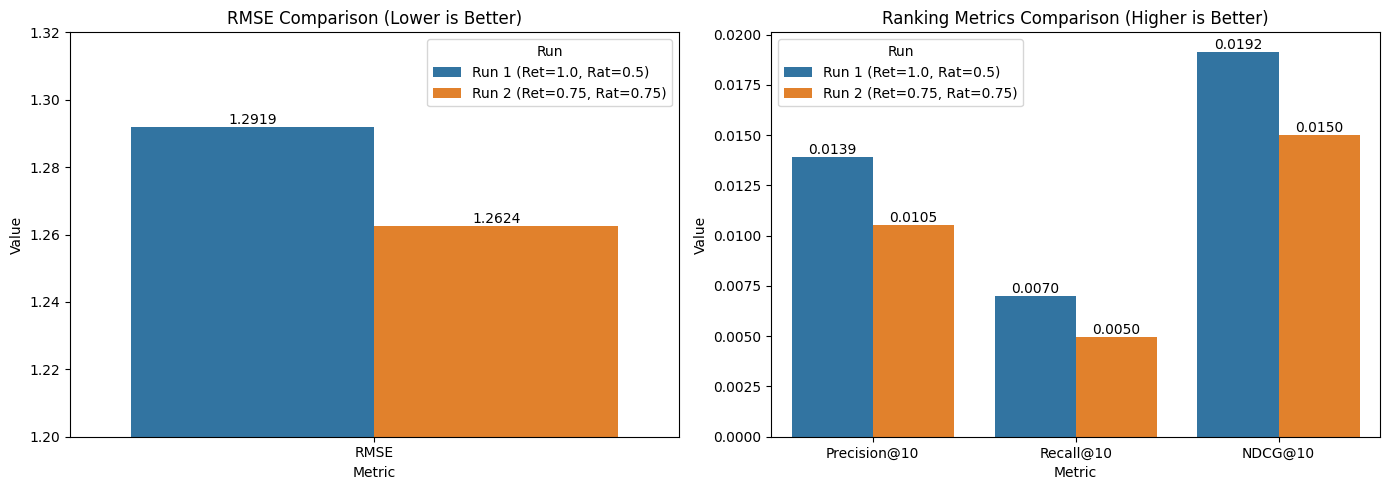

Run,"Run 1 (Ret=1.0, Rat=0.5)","Run 2 (Ret=0.75, Rat=0.75)"
Metric,,
NDCG@10,0.019154,0.015001
Precision@10,0.013909,0.010523
RMSE,1.291907,1.262390
Recall@10,0.007008,0.004969


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hardcoding the metrics from the training cell comments
run_comparison_data = [
    {"Run": "Run 1 (Ret=1.0, Rat=0.5)", "Metric": "RMSE", "Value": 1.291907},
    {"Run": "Run 1 (Ret=1.0, Rat=0.5)", "Metric": "Precision@10", "Value": 0.013909},
    {"Run": "Run 1 (Ret=1.0, Rat=0.5)", "Metric": "Recall@10", "Value": 0.007008},
    {"Run": "Run 1 (Ret=1.0, Rat=0.5)", "Metric": "NDCG@10", "Value": 0.019154},

    {"Run": "Run 2 (Ret=0.75, Rat=0.75)", "Metric": "RMSE", "Value": 1.262390},
    {"Run": "Run 2 (Ret=0.75, Rat=0.75)", "Metric": "Precision@10", "Value": 0.010523},
    {"Run": "Run 2 (Ret=0.75, Rat=0.75)", "Metric": "Recall@10", "Value": 0.004969},
    {"Run": "Run 2 (Ret=0.75, Rat=0.75)", "Metric": "NDCG@10", "Value": 0.015001},
]

df_comp = pd.DataFrame(run_comparison_data)

# Create subplots for RMSE vs Ranking metrics because of scale differences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE
rmse_df = df_comp[df_comp["Metric"] == "RMSE"]
sns.barplot(data=rmse_df, x="Metric", y="Value", hue="Run", ax=axes[0])
axes[0].set_title("RMSE Comparison (Lower is Better)")
axes[0].set_ylim(1.2, 1.32)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f')

# Plot Ranking Metrics
ranking_df = df_comp[df_comp["Metric"] != "RMSE"]
sns.barplot(data=ranking_df, x="Metric", y="Value", hue="Run", ax=axes[1])
axes[1].set_title("Ranking Metrics Comparison (Higher is Better)")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()

# Display tabular format
pivot_comp = df_comp.pivot(index="Metric", columns="Run", values="Value")
display(pivot_comp)

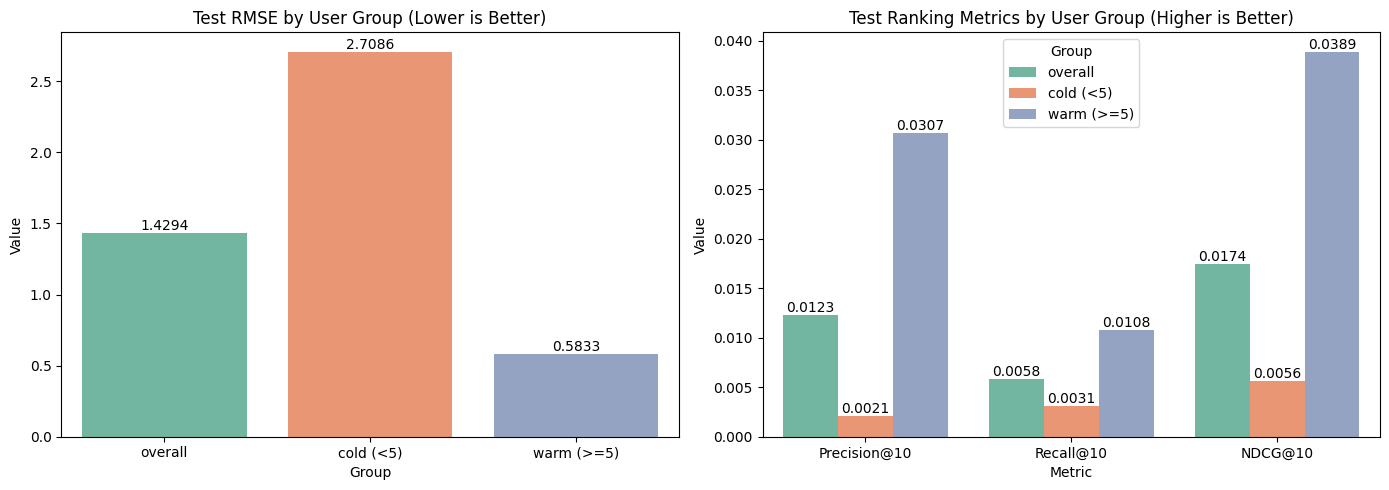

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting from test results
groups = ["overall", "cold (<5)", "warm (>=5)"]

rmse_data = []
for g in groups:
    rmse_data.append({"Group": g, "Metric": "RMSE", "Value": test_rmse[g]["rmse"]})

rank_data = []
for g in groups:
    rank_data.append({"Group": g, "Metric": "Precision@10", "Value": test_rank_metrics[g]["precision@10"]})
    rank_data.append({"Group": g, "Metric": "Recall@10", "Value": test_rank_metrics[g]["recall@10"]})
    rank_data.append({"Group": g, "Metric": "NDCG@10", "Value": test_rank_metrics[g]["ndcg@10"]})

df_rmse = pd.DataFrame(rmse_data)
df_rank = pd.DataFrame(rank_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE
sns.barplot(data=df_rmse, x="Group", y="Value", hue="Group", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Test RMSE by User Group (Lower is Better)")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f')

# Plot Ranking Metrics
sns.barplot(data=df_rank, x="Metric", y="Value", hue="Group", ax=axes[1], palette="Set2")
axes[1].set_title("Test Ranking Metrics by User Group (Higher is Better)")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()
